In [1]:
!pip install hopsworks["python"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hopsworks
from google.colab import userdata

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [ ]:
api_key = userdata.get("HOPSWORKS_API_KEY")

In [ ]:
project = hopsworks.login(
        project='PearlsAQI_Project',
        host="eu-west.cloud.hopsworks.ai",
        port=443,
        api_key_value=api_key,
)

fs = project.get_feature_store()
fg = fs.get_feature_group(name="karachi_aqi",version=1)


Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41138


In [ ]:
df = fg.read()
df

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (88.96s) 


,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,ammonia,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
0,2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,NaN,68,27.1,85,16.5,232,1001.6,0.0,19,Karachi
1,2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,NaN,68,27.9,79,18.8,230,1000.6,0.0,80,Karachi
2,2026-08-22 11:00:00,23.5,63.8,184.0,4.4,4.5,60.0,64.0,NaN,67,29.6,70,19.6,252,1003.4,0.0,100,Karachi
3,2026-08-22 10:00:00,23.3,63.8,205.0,6.0,4.6,54.0,58.0,NaN,66,29.3,69,20.6,256,1004.5,0.0,100,Karachi
4,2026-08-22 09:00:00,21.8,58.7,234.0,7.9,4.7,47.0,50.0,NaN,66,28.9,70,20.2,254,1004.6,0.0,97,Karachi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18039,2026-08-21 18:00:00,18.4,46.1,243.0,9.1,4.7,47.0,49.0,NaN,63,28.0,81,16.9,237,1001.6,0.2,93,Karachi
18040,2026-08-21 19:00:00,18.3,41.8,235.0,11.2,4.7,43.0,48.0,NaN,63,27.3,86,17.2,237,1001.9,0.1,94,Karachi
18041,2026-08-21 20:00:00,20.7,51.0,225.0,12.4,4.8,41.0,45.0,NaN,63,27.2,86,17.5,235,1002.5,0.3,100,Karachi
18042,2026-08-21 21:00:00,17.7,43.8,215.0,12.2,4.8,40.0,40.0,NaN,64,27.2,86,17.9,236,1003.0,0.2,100,Karachi


- `ammonia` column doesn't have any value so dropping it.

In [ ]:
df.drop("ammonia",axis=1,inplace=True)

- saving the file because we are going to use data till 2026-08-22 21:00:00 for EDA and initial model training.

In [ ]:
df.to_csv(f"AQI_data_till_{df["timestamp"].max()}.csv")

In [ ]:
aqi = pd.read_csv("AQI_data_till_2026-08-22 21_00_00.csv")
aqi

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
0,0,2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68,27.1,85,16.5,232,1001.6,0.0,19,Karachi
1,1,2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68,27.9,79,18.8,230,1000.6,0.0,80,Karachi
2,2,2026-08-22 11:00:00,23.5,63.8,184.0,4.4,4.5,60.0,64.0,67,29.6,70,19.6,252,1003.4,0.0,100,Karachi
3,3,2026-08-22 10:00:00,23.3,63.8,205.0,6.0,4.6,54.0,58.0,66,29.3,69,20.6,256,1004.5,0.0,100,Karachi
4,4,2026-08-22 09:00:00,21.8,58.7,234.0,7.9,4.7,47.0,50.0,66,28.9,70,20.2,254,1004.6,0.0,97,Karachi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18039,18039,2026-08-21 18:00:00,18.4,46.1,243.0,9.1,4.7,47.0,49.0,63,28.0,81,16.9,237,1001.6,0.2,93,Karachi
18040,18040,2026-08-21 19:00:00,18.3,41.8,235.0,11.2,4.7,43.0,48.0,63,27.3,86,17.2,237,1001.9,0.1,94,Karachi
18041,18041,2026-08-21 20:00:00,20.7,51.0,225.0,12.4,4.8,41.0,45.0,63,27.2,86,17.5,235,1002.5,0.3,100,Karachi
18042,18042,2026-08-21 21:00:00,17.7,43.8,215.0,12.2,4.8,40.0,40.0,64,27.2,86,17.9,236,1003.0,0.2,100,Karachi


In [ ]:
df = aqi.copy()
df.head()

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
0,0,2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68,27.1,85,16.5,232,1001.6,0.0,19,Karachi
1,1,2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68,27.9,79,18.8,230,1000.6,0.0,80,Karachi
2,2,2026-08-22 11:00:00,23.5,63.8,184.0,4.4,4.5,60.0,64.0,67,29.6,70,19.6,252,1003.4,0.0,100,Karachi
3,3,2026-08-22 10:00:00,23.3,63.8,205.0,6.0,4.6,54.0,58.0,66,29.3,69,20.6,256,1004.5,0.0,100,Karachi
4,4,2026-08-22 09:00:00,21.8,58.7,234.0,7.9,4.7,47.0,50.0,66,28.9,70,20.2,254,1004.6,0.0,97,Karachi


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18044 entries, 0 to 18043
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            18044 non-null  int64  
 1   timestamp             18044 non-null  object 
 2   pm2_5                 18044 non-null  float64
 3   pm10                  18044 non-null  float64
 4   carbon_monoxide       18044 non-null  float64
 5   nitrogen_dioxide      18044 non-null  float64
 6   sulphur_dioxide       18044 non-null  float64
 7   ozone                 18044 non-null  float64
 8   dust                  18044 non-null  float64
 9   us_aqi                18044 non-null  int64  
 10  temperature_2m        18044 non-null  float64
 11  relative_humidity_2m  18044 non-null  int64  
 12  wind_speed_10m        18044 non-null  float64
 13  wind_direction_10m    18044 non-null  int64  
 14  surface_pressure      18044 non-null  float64
 15  precipitation      

In [ ]:
df.head()

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
0,0,2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68,27.1,85,16.5,232,1001.6,0.0,19,Karachi
1,1,2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68,27.9,79,18.8,230,1000.6,0.0,80,Karachi
2,2,2026-08-22 11:00:00,23.5,63.8,184.0,4.4,4.5,60.0,64.0,67,29.6,70,19.6,252,1003.4,0.0,100,Karachi
3,3,2026-08-22 10:00:00,23.3,63.8,205.0,6.0,4.6,54.0,58.0,66,29.3,69,20.6,256,1004.5,0.0,100,Karachi
4,4,2026-08-22 09:00:00,21.8,58.7,234.0,7.9,4.7,47.0,50.0,66,28.9,70,20.2,254,1004.6,0.0,97,Karachi


#### Looking for duplicates and missing values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum().sum()

np.int64(0)

- no duplicates and no missing values

#### Sorting the `timestamp` column

In [ ]:
df["timestamp"] = df["timestamp"].sort_values()

In [ ]:
df.tail(20)

,Unnamed: 0,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
18024,18024,2026-08-21 03:00:00,11.9,25.0,112.0,6.4,4.3,38.0,16.0,62,26.7,85,12.6,253,1002.9,0.0,79,Karachi
18025,18025,2026-08-21 04:00:00,11.8,25.6,106.0,5.7,4.3,39.0,18.0,62,26.6,86,13.6,253,1002.8,0.0,78,Karachi
18026,18026,2026-08-21 05:00:00,11.8,25.8,120.0,5.6,4.4,40.0,20.0,62,26.8,85,14.0,258,1003.1,0.0,45,Karachi
18027,18027,2026-08-21 06:00:00,12.3,27.0,173.0,7.0,4.8,39.0,23.0,62,26.8,86,13.5,260,1003.6,0.0,91,Karachi
18028,18028,2026-08-21 07:00:00,14.2,31.3,244.0,8.8,5.3,38.0,28.0,62,27.1,84,12.8,261,1004.1,0.0,91,Karachi
18029,18029,2026-08-21 08:00:00,15.2,37.0,288.0,9.7,5.6,39.0,34.0,62,27.8,79,14.4,260,1004.5,0.0,98,Karachi
18030,18030,2026-08-21 09:00:00,19.7,53.0,275.0,8.7,5.6,45.0,41.0,62,28.7,74,15.7,253,1004.9,0.0,100,Karachi
18031,18031,2026-08-21 10:00:00,20.3,55.3,234.0,6.6,5.4,53.0,48.0,62,28.9,74,16.4,245,1004.9,0.1,100,Karachi
18032,18032,2026-08-21 11:00:00,20.5,54.2,201.0,5.0,5.2,59.0,53.0,62,29.6,70,17.8,242,1005.0,0.1,100,Karachi
18033,18033,2026-08-21 12:00:00,19.4,49.4,191.0,4.2,5.0,63.0,53.0,62,29.3,71,17.2,242,1004.5,0.1,100,Karachi


#### Looking for some missing rows

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

expected = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="h"
)

missing_rows = expected.difference(df["timestamp"])

print("Number of missing rows:", len(missing_rows))
print(missing_rows)

Number of missing rows: 2
DatetimeIndex(['2026-08-22 05:00:00', '2026-08-22 07:00:00'], dtype='datetime64[ns]', freq=None)


- some rows are missing because github does the schedule task of adding new rows very late due to which some hours are missing but the good thing is only one hour is missing in between not a series of hours so we can use time interpolation

In [ ]:
df.set_index("timestamp",inplace=True)


In [ ]:
df.drop("Unnamed: 0",axis=1,inplace=True)



In [ ]:
full_index = pd.date_range(
    df.index.min(),
    df.index.max(),
    freq="h"
)
df = df.reindex(full_index)

In [ ]:
df

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
2024-08-01 00:00:00,20.5,46.8,217.0,14.6,4.6,43.0,42.0,66.0,28.7,88.0,23.3,235.0,998.9,0.0,62.0,Karachi
2024-08-01 01:00:00,18.9,46.0,180.0,10.5,4.0,45.0,47.0,66.0,28.6,88.0,22.4,240.0,998.3,0.0,94.0,Karachi
2024-08-01 02:00:00,17.9,46.4,152.0,7.4,3.6,47.0,51.0,66.0,28.6,87.0,22.6,245.0,997.9,0.0,82.0,Karachi
2024-08-01 03:00:00,17.2,47.1,136.0,5.8,3.4,48.0,53.0,66.0,28.7,85.0,23.9,249.0,997.6,0.0,100.0,Karachi
2024-08-01 04:00:00,16.9,47.1,128.0,5.1,3.5,48.0,53.0,66.0,28.6,85.0,24.4,254.0,997.9,0.0,96.0,Karachi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-22 17:00:00,20.3,47.7,250.0,7.6,4.3,50.0,39.0,68.0,28.3,76.0,18.2,231.0,1000.5,0.0,99.0,Karachi
2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68.0,27.9,79.0,18.8,230.0,1000.6,0.0,80.0,Karachi
2026-08-22 19:00:00,20.2,44.6,255.0,10.6,4.4,44.0,31.0,68.0,27.3,83.0,18.1,230.0,1001.0,0.0,33.0,Karachi
2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68.0,27.1,85.0,16.5,232.0,1001.6,0.0,19.0,Karachi


In [ ]:
df.set_index(pd.to_datetime(df.index),inplace=True)
df = df.interpolate(method="time",limit=2)


In [ ]:
df.sort_index().tail(20)

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
2026-08-22 02:00:00,16.20,40.50,123.0,5.1,3.70,46.0,37.0,65.0,26.5,87.0,15.40,247.0,1002.70,0.0,100.0,Karachi
2026-08-22 03:00:00,13.50,30.20,114.0,5.3,3.90,44.0,24.0,66.0,26.5,88.0,16.10,248.0,1002.40,0.0,99.0,Karachi
2026-08-22 04:00:00,13.20,29.60,112.0,4.9,4.10,44.0,24.0,66.0,26.4,88.0,16.80,252.0,1002.20,0.0,100.0,Karachi
2026-08-22 05:00:00,13.25,30.15,137.0,5.6,4.25,43.0,27.0,66.0,26.5,86.5,15.55,254.0,1002.80,0.0,68.0,NaN
2026-08-22 06:00:00,13.30,30.70,162.0,6.3,4.40,42.0,30.0,66.0,26.6,85.0,14.30,256.0,1003.40,0.0,36.0,Karachi
2026-08-22 07:00:00,14.90,36.65,202.5,7.6,4.55,42.0,36.0,66.0,27.4,79.5,16.35,255.0,1003.85,0.0,59.5,NaN
2026-08-22 08:00:00,16.50,42.60,243.0,8.9,4.70,42.0,42.0,66.0,28.2,74.0,18.40,254.0,1004.30,0.0,83.0,Karachi
2026-08-22 09:00:00,21.80,58.70,234.0,7.9,4.70,47.0,50.0,66.0,28.9,70.0,20.20,254.0,1004.60,0.0,97.0,Karachi
2026-08-22 10:00:00,23.30,63.80,205.0,6.0,4.60,54.0,58.0,66.0,29.3,69.0,20.60,256.0,1004.50,0.0,100.0,Karachi
2026-08-22 11:00:00,23.50,63.80,184.0,4.4,4.50,60.0,64.0,67.0,29.6,70.0,19.60,252.0,1003.40,0.0,100.0,Karachi


In [ ]:
df.isna().sum()

,0
pm2_5,0
pm10,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
dust,0
us_aqi,0
temperature_2m,0
relative_humidity_2m,0


there is NAN in the `city` column for missing rows that we interpolated so for now we are just going to make every value in city to Karachi beacuse we are just using the  karachi data for now.

In [ ]:
df["city"] = "Karachi"

In [ ]:
df.isna().sum()

,0
pm2_5,0
pm10,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
dust,0
us_aqi,0
temperature_2m,0
relative_humidity_2m,0


In [ ]:
df.tail(20)

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city
2026-08-22 02:00:00,16.20,40.50,123.0,5.1,3.70,46.0,37.0,65.0,26.5,87.0,15.40,247.0,1002.70,0.0,100.0,Karachi
2026-08-22 03:00:00,13.50,30.20,114.0,5.3,3.90,44.0,24.0,66.0,26.5,88.0,16.10,248.0,1002.40,0.0,99.0,Karachi
2026-08-22 04:00:00,13.20,29.60,112.0,4.9,4.10,44.0,24.0,66.0,26.4,88.0,16.80,252.0,1002.20,0.0,100.0,Karachi
2026-08-22 05:00:00,13.25,30.15,137.0,5.6,4.25,43.0,27.0,66.0,26.5,86.5,15.55,254.0,1002.80,0.0,68.0,Karachi
2026-08-22 06:00:00,13.30,30.70,162.0,6.3,4.40,42.0,30.0,66.0,26.6,85.0,14.30,256.0,1003.40,0.0,36.0,Karachi
2026-08-22 07:00:00,14.90,36.65,202.5,7.6,4.55,42.0,36.0,66.0,27.4,79.5,16.35,255.0,1003.85,0.0,59.5,Karachi
2026-08-22 08:00:00,16.50,42.60,243.0,8.9,4.70,42.0,42.0,66.0,28.2,74.0,18.40,254.0,1004.30,0.0,83.0,Karachi
2026-08-22 09:00:00,21.80,58.70,234.0,7.9,4.70,47.0,50.0,66.0,28.9,70.0,20.20,254.0,1004.60,0.0,97.0,Karachi
2026-08-22 10:00:00,23.30,63.80,205.0,6.0,4.60,54.0,58.0,66.0,29.3,69.0,20.60,256.0,1004.50,0.0,100.0,Karachi
2026-08-22 11:00:00,23.50,63.80,184.0,4.4,4.50,60.0,64.0,67.0,29.6,70.0,19.60,252.0,1003.40,0.0,100.0,Karachi


In [ ]:
df["month_name"] = df.index.month_name()
df["day"] = df.index.day
df["day_name"] = df.index.day_name()
df["hour"] = df.index.hour

In [ ]:
df

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,cloud_cover,city,month_name,day,day_name,hour
2024-08-01 00:00:00,20.5,46.8,217.0,14.6,4.6,43.0,42.0,66.0,28.7,88.0,23.3,235.0,998.9,0.0,62.0,Karachi,August,1,Thursday,0
2024-08-01 01:00:00,18.9,46.0,180.0,10.5,4.0,45.0,47.0,66.0,28.6,88.0,22.4,240.0,998.3,0.0,94.0,Karachi,August,1,Thursday,1
2024-08-01 02:00:00,17.9,46.4,152.0,7.4,3.6,47.0,51.0,66.0,28.6,87.0,22.6,245.0,997.9,0.0,82.0,Karachi,August,1,Thursday,2
2024-08-01 03:00:00,17.2,47.1,136.0,5.8,3.4,48.0,53.0,66.0,28.7,85.0,23.9,249.0,997.6,0.0,100.0,Karachi,August,1,Thursday,3
2024-08-01 04:00:00,16.9,47.1,128.0,5.1,3.5,48.0,53.0,66.0,28.6,85.0,24.4,254.0,997.9,0.0,96.0,Karachi,August,1,Thursday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-22 17:00:00,20.3,47.7,250.0,7.6,4.3,50.0,39.0,68.0,28.3,76.0,18.2,231.0,1000.5,0.0,99.0,Karachi,August,22,Saturday,17
2026-08-22 18:00:00,20.4,47.3,256.0,9.1,4.4,47.0,35.0,68.0,27.9,79.0,18.8,230.0,1000.6,0.0,80.0,Karachi,August,22,Saturday,18
2026-08-22 19:00:00,20.2,44.6,255.0,10.6,4.4,44.0,31.0,68.0,27.3,83.0,18.1,230.0,1001.0,0.0,33.0,Karachi,August,22,Saturday,19
2026-08-22 20:00:00,17.3,38.0,250.0,11.5,4.5,42.0,29.0,68.0,27.1,85.0,16.5,232.0,1001.6,0.0,19.0,Karachi,August,22,Saturday,20


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18046 entries, 2024-08-01 00:00:00 to 2026-08-22 21:00:00
Freq: h
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pm2_5                 18046 non-null  float64
 1   pm10                  18046 non-null  float64
 2   carbon_monoxide       18046 non-null  float64
 3   nitrogen_dioxide      18046 non-null  float64
 4   sulphur_dioxide       18046 non-null  float64
 5   ozone                 18046 non-null  float64
 6   dust                  18046 non-null  float64
 7   us_aqi                18046 non-null  float64
 8   temperature_2m        18046 non-null  float64
 9   relative_humidity_2m  18046 non-null  float64
 10  wind_speed_10m        18046 non-null  float64
 11  wind_direction_10m    18046 non-null  float64
 12  surface_pressure      18046 non-null  float64
 13  precipitation         18046 non-null  float64
 14  cloud_cover           18046

In [ ]:
def plot_distribution_profile(data, column_name):
    """Plots a histogram with KDE and prints detailed skewness metrics."""
    # 1. Calculate statistical metrics
    skewness = data[column_name].skew()
    mean_val = data[column_name].mean()
    median_val = data[column_name].median()

    # Determine skewness type
    if skewness > 0.5:
        skew_type = "Positively Skewed (Right-tailed)"
    elif skewness < -0.5:
        skew_type = "Negatively Skewed (Left-tailed)"
    else:
        skew_type = "Approximately Symmetric"

    # 2. Print detailed text analysis
    print("=" * 45)
    print(f"      DISTRIBUTION PROFILE: {column_name.upper()}      ")
    print("=" * 45)
    print(f"Skewness Score : {skewness:.4f}")
    print(f"Skewness Type  : {skew_type}")
    print("-" * 45)
    print(f"Mean Value     : {mean_val:.2f}")
    print(f"Median Value   : {median_val:.2f}")
    print(f"Difference     : {abs(mean_val - median_val):.2f}")
    print("=" * 45)

    # 3. Create the visualization
    plt.figure(figsize=(10, 6))

    # Plot histogram + KDE curve
    sns.histplot(
        data=data, x=column_name, kde=True, color="skyblue", stat="density"
    )

    # Add reference lines for Mean and Median
    plt.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean ({mean_val:.1f})",
    )
    plt.axvline(
        median_val,
        color="green",
        linestyle="-",
        linewidth=2,
        label=f"Median ({median_val:.1f})",
    )

    # Formatting details
    plt.title(
        f"Distribution & Skewness Analysis for {column_name}",
        fontsize=14,
        pad=15,
    )
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(axis="y", alpha=0.3)

    plt.show()

def check_outliers_and_plot_box(data,column_name):
    ax = sns.boxplot(y=data[column_name])
    plt.show()

    min_whisker_value = ax.lines[0].get_ydata().min()
    max_whisker_value = ax.lines[1].get_ydata().max()

    # 2. Calculate counts using single quotes inside the f-string/brackets to avoid SyntaxError
    total_records = len(data[column_name])
    high_outliers_count = (data[column_name] > max_whisker_value).sum()
    low_outliers_count = (data[column_name] < min_whisker_value).sum()
    total_outliers_count = high_outliers_count + low_outliers_count

    # 3. Calculate percentages
    high_outliers_pct = (high_outliers_count / total_records) * 100
    low_outliers_pct = (low_outliers_count / total_records) * 100
    total_outliers_pct = (total_outliers_count / total_records) * 100

    # Detailed Print Profile
    print("=" * 45)
    print(f"          {column_name.upper()} OUTLIER ANALYSIS           ")
    print("=" * 45)
    print(f"Total Dataset Records  : {total_records:,}")
    print(f"Lower Whisker Boundary : {min_whisker_value:.2f}")
    print(f"Upper Whisker Boundary : {max_whisker_value:.2f}")
    print("-" * 45)
    print(f"Low Outliers (< {min_whisker_value:.2f})  : {low_outliers_count:,} ({low_outliers_pct:.3f}%)")
    print(f"High Outliers (> {max_whisker_value:.2f}) : {high_outliers_count:,} ({high_outliers_pct:.3f}%)")
    print("-" * 45)
    print(f"Total Outliers Found   : {total_outliers_count:,} ({total_outliers_pct:.3f}%)")
    print(f"Clean Records remaining: {total_records - total_outliers_count:,}")
    print("=" * 45)

## EDA

### 1. Univariate Analysis:

#### a. `pm2_5` column:   
PM2.5 means particulate matter with a width of 2.5 micrometers or less. These microscopic solid or liquid pieces float in the air. They are about 30 times smaller than a human hair.


In [ ]:
df["pm2_5"].describe()

,pm2_5
count,18046.000000
mean,27.981572
std,12.608667
min,3.500000
25%,19.400000
50%,24.900000
75%,33.200000
max,108.700000


      DISTRIBUTION PROFILE: PM2_5      
Skewness Score : 1.5408
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 27.98
Median Value   : 24.90
Difference     : 3.08


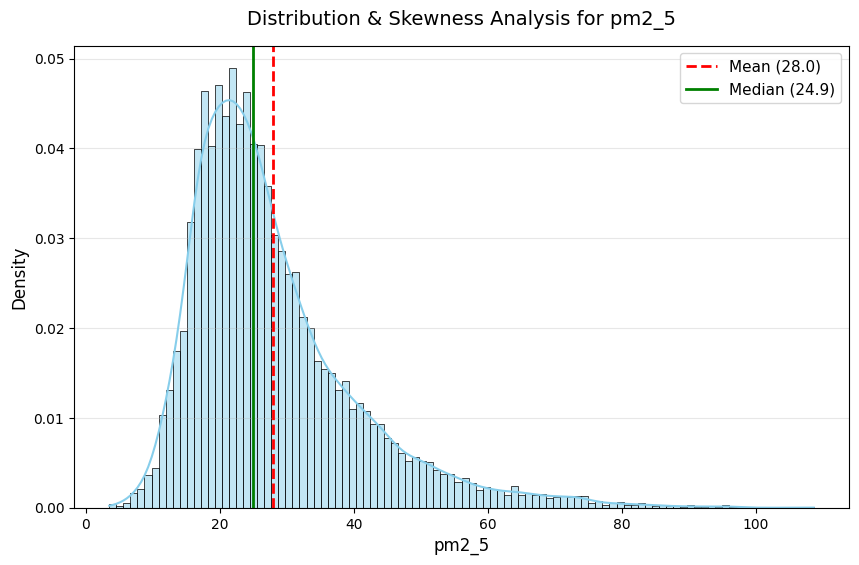

In [ ]:
plot_distribution_profile(df, "pm2_5")

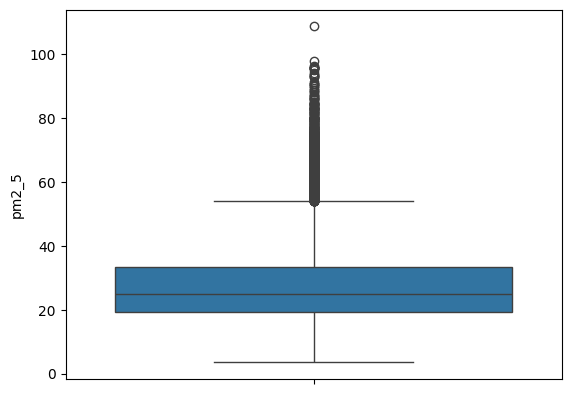

          PM2_5 OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 3.50
Upper Whisker Boundary : 53.90
---------------------------------------------
Low Outliers (< 3.50)  : 0 (0.000%)
High Outliers (> 53.90) : 844 (4.677%)
---------------------------------------------
Total Outliers Found   : 844 (4.677%)
Clean Records remaining: 17,202


In [ ]:
check_outliers_and_plot_box(df,"pm2_5")

- Right skewed
- ~5% outlier only outside the upper whisker boundary

#### b. `pm10` column:
PM10 means particulate matter with a diameter of 10 micrometers or smaller (about one-seventh the width of a human hair). It is a measure of coarse dust, smoke, soot, and liquid droplets mixed in the air


In [ ]:
df["pm10"].describe()

,pm10
count,18046.000000
mean,55.701180
std,32.289981
min,3.700000
25%,36.100000
50%,48.700000
75%,66.800000
max,504.800000


      DISTRIBUTION PROFILE: PM10      
Skewness Score : 3.0012
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 55.70
Median Value   : 48.70
Difference     : 7.00


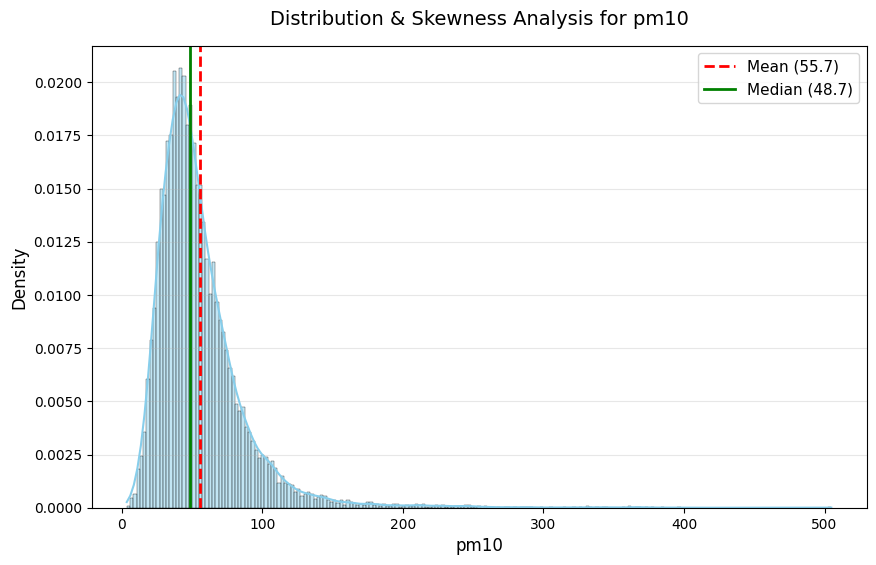

In [ ]:
plot_distribution_profile(df, "pm10")

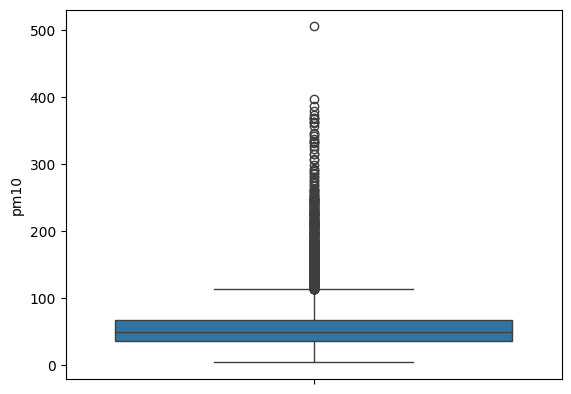

          PM10 OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 3.70
Upper Whisker Boundary : 112.70
---------------------------------------------
Low Outliers (< 3.70)  : 0 (0.000%)
High Outliers (> 112.70) : 810 (4.489%)
---------------------------------------------
Total Outliers Found   : 810 (4.489%)
Clean Records remaining: 17,236


In [ ]:
check_outliers_and_plot_box(df,"pm10")

- highly right skewed
- ~4.5% outliers only outside the upper whisker boundary

#### c. `carbon_monoxide` column:
The `carbon_monoxide` column records ambient Carbon Monoxide concentrations, which serve as one of the major criteria pollutants used to calculate the localized Air Quality Index (AQI). CO is a hazardous, odorless gas primarily emitted by vehicle exhaust and industrial combustion.

In [ ]:
df["carbon_monoxide"].describe()

,carbon_monoxide
count,18046.000000
mean,501.389311
std,443.651622
min,46.000000
25%,222.000000
50%,327.000000
75%,623.000000
max,4515.000000


      DISTRIBUTION PROFILE: CARBON_MONOXIDE      
Skewness Score : 2.5156
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 501.39
Median Value   : 327.00
Difference     : 174.39


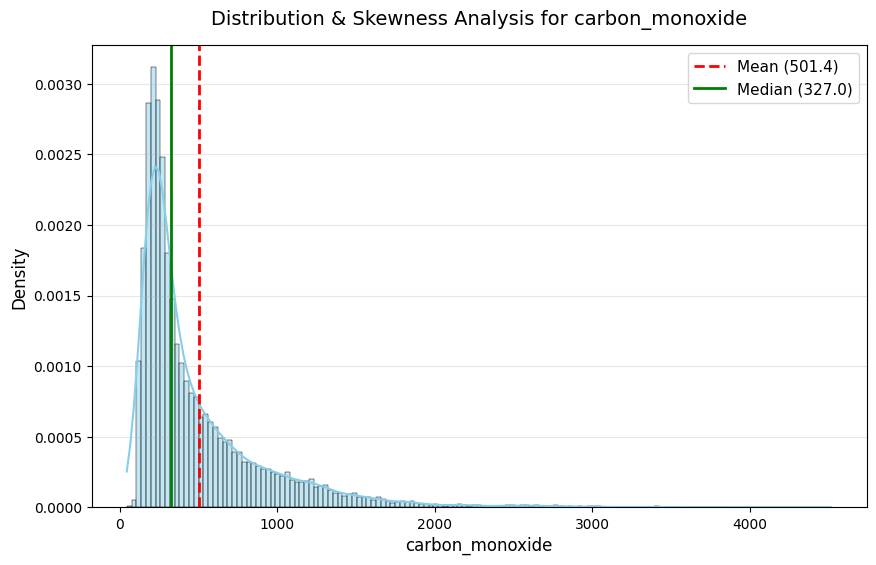

In [ ]:
plot_distribution_profile(df, "carbon_monoxide")

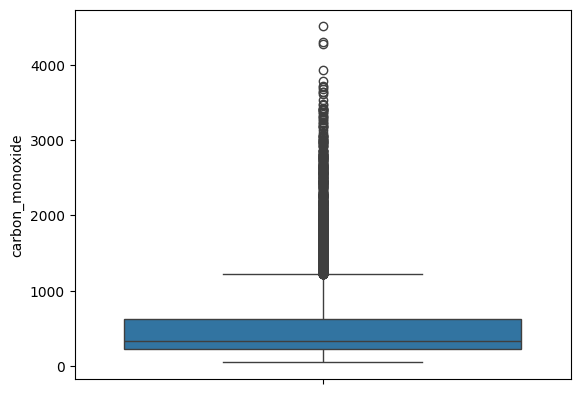

          CARBON_MONOXIDE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 46.00
Upper Whisker Boundary : 1224.00
---------------------------------------------
Low Outliers (< 46.00)  : 0 (0.000%)
High Outliers (> 1224.00) : 1,288 (7.137%)
---------------------------------------------
Total Outliers Found   : 1,288 (7.137%)
Clean Records remaining: 16,758


In [ ]:
check_outliers_and_plot_box(df,"carbon_monoxide")

#### d. `nitrogen_dioxide` column:
The `nitrogen_dioxide` column measures ambient Nitrogen Dioxide concentrations, a highly reactive gas that serves as a core component in determining the overall Air Quality Index (AQI). $\text{NO}_2$ forms primarily from high-temperature fuel combustion, with major sources including motor vehicle engines, power plants, and heavy off-road equipment. Monitoring $\text{NO}_2$ within the AQI framework is vital because it acts as a precursor to both ground-level ozone $\text{O}_3$ and fine particulate matter $\text{NO}_2$, making it a key indicator of traffic-related photochemical smog and acute respiratory health risks.

In [ ]:
df["nitrogen_dioxide"].describe()

,nitrogen_dioxide
count,18046.000000
mean,19.896947
std,18.429160
min,0.000000
25%,7.300000
50%,13.100000
75%,26.200000
max,138.500000


      DISTRIBUTION PROFILE: NITROGEN_DIOXIDE      
Skewness Score : 1.9738
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 19.90
Median Value   : 13.10
Difference     : 6.80


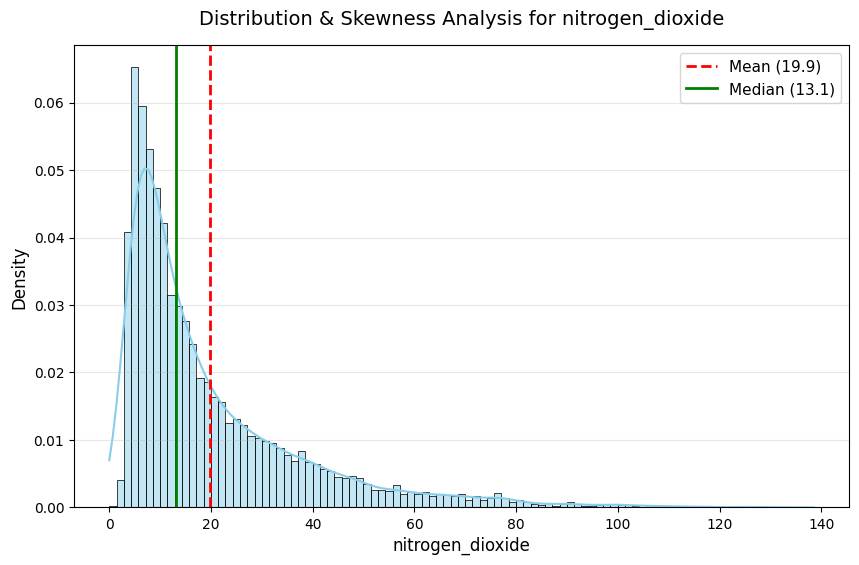

In [ ]:
plot_distribution_profile(df, "nitrogen_dioxide")

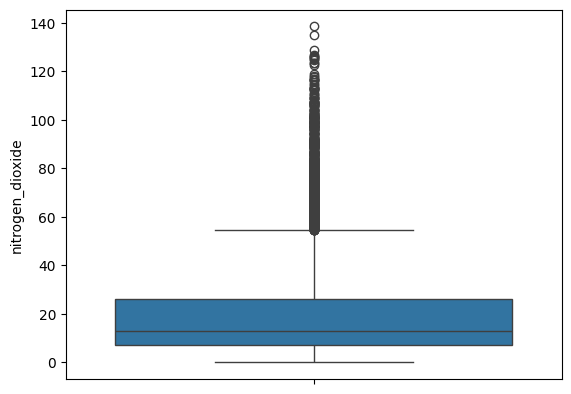

          NITROGEN_DIOXIDE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 0.00
Upper Whisker Boundary : 54.50
---------------------------------------------
Low Outliers (< 0.00)  : 0 (0.000%)
High Outliers (> 54.50) : 1,115 (6.179%)
---------------------------------------------
Total Outliers Found   : 1,115 (6.179%)
Clean Records remaining: 16,931


In [ ]:
check_outliers_and_plot_box(df,"nitrogen_dioxide")

#### e. `sulphur_dioxide` column:
The sulphur_dioxide $(\text{SO}_{2})$ column tracks ambient levels of a highly reactive gas that is an official US EPA criteria pollutant used to calculate the daily AQI. $\text{SO}_{2}$ enters the atmosphere primarily through the burning of fossil fuels at power plants, industrial facilities, and from heavy machinery or ships operating on high-sulfur diesel fuel. Monitoring this column is critical because atmospheric $\text{SO}_{2}$ reacts with other compounds to form secondary fine particulate matter $\text{PM}_{2.5}$ and is the primary driver behind acid rain.

In [ ]:
df["sulphur_dioxide"].describe()

,sulphur_dioxide
count,18046.000000
mean,13.828959
std,8.630047
min,2.600000
25%,7.200000
50%,12.100000
75%,17.700000
max,65.400000


      DISTRIBUTION PROFILE: SULPHUR_DIOXIDE      
Skewness Score : 1.5082
Skewness Type  : Positively Skewed (Right-tailed)
---------------------------------------------
Mean Value     : 13.83
Median Value   : 12.10
Difference     : 1.73


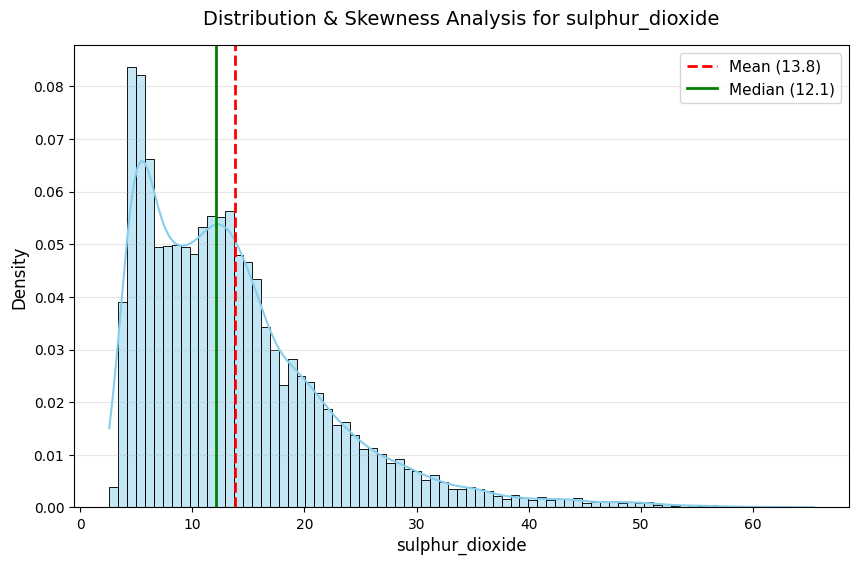

In [ ]:
plot_distribution_profile(df, "sulphur_dioxide")

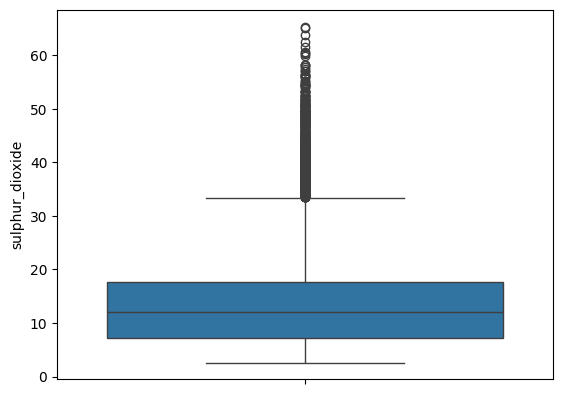

          SULPHUR_DIOXIDE OUTLIER ANALYSIS           
Total Dataset Records  : 18,046
Lower Whisker Boundary : 2.60
Upper Whisker Boundary : 33.40
---------------------------------------------
Low Outliers (< 2.60)  : 0 (0.000%)
High Outliers (> 33.40) : 639 (3.541%)
---------------------------------------------
Total Outliers Found   : 639 (3.541%)
Clean Records remaining: 17,407


In [ ]:
check_outliers_and_plot_box(df,"sulphur_dioxide")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18046 entries, 2024-08-01 00:00:00 to 2026-08-22 21:00:00
Freq: h
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pm2_5                 18046 non-null  float64
 1   pm10                  18046 non-null  float64
 2   carbon_monoxide       18046 non-null  float64
 3   nitrogen_dioxide      18046 non-null  float64
 4   sulphur_dioxide       18046 non-null  float64
 5   ozone                 18046 non-null  float64
 6   dust                  18046 non-null  float64
 7   us_aqi                18046 non-null  float64
 8   temperature_2m        18046 non-null  float64
 9   relative_humidity_2m  18046 non-null  float64
 10  wind_speed_10m        18046 non-null  float64
 11  wind_direction_10m    18046 non-null  float64
 12  surface_pressure      18046 non-null  float64
 13  precipitation         18046 non-null  float64
 14  cloud_cover           18046